<center><h1> WCA Analysis - Summary of the Italian speedcubing community </h1></center>

<b>Speedcubing</b> or <b>Speedsolving</b> is the activity of solving a variety of twisty puzzles as fast as possible.

The <b>World Cube Association</b> (abbreviated as WCA) is the ruling and organizing entity for speedsolving Rubik's Cube and other puzzles. Although the WCA has no legal status, it is regarded by all top speedcubers as the official organization for cubing competitions and records.

The WCA has a public database containing public information about all official WCA
competitions, WCA members, and WCA competition results since 2003. You can download it for free [here](https://www.worldcubeassociation.org/results/misc/export.html).

This document presents a collection of statistics from this database, with a focus on the [Italian speedcubing community](https://www.instagram.com/cubingitaly/?hl=it).

<small><i>Updated on June 25th 2022.</i></small>

# Table of contents

- [Data import](#imports)
- [Competitions](#comps)
    - Number of competitions
    - Number of competitions abroad
    - Number of countries competed in
    - Newcomers and Competitors
    - Return Rate
    - Regions competed in
    - Competition distribution
- [Events](#events)
    - Most Events Won
    - Most Events Podiumed
    - Most Popular Events
    - Average Events per competition
- [Results](#results)
    - Medal table
    - Current best world rankings
    - Most top 10 rankings
    - Best podiums of all time
    - Best first average
- [Records](#records)
    - Italian World and Continental records
    - Evolution of 3x3 National Records
- [Relays](#relays)
     - 2-7 relay
     - Guilford Challenge
     - Mini Guilford Challenge
     - Lucky

# Data Import <a name="imports"></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12, 6)

Results:

In [2]:
Results = pd.read_csv('WCA_export_Results.tsv', sep='\t')

Competitions:

In [3]:
Competitions = pd.read_csv('WCA_export_Competitions.tsv', sep='\t')

The <i>Results</i> and <i>Competitions</i> datasets are the main ones we are going to be using. 

For every result at each competition I will need to access the information about said competition, so I merge the two datasets:

In [4]:
df = Results.merge(Competitions, how='left', left_on='competitionId', right_on='id', validate = "m:1")
df = df.drop('id', 1)

In [5]:
df = df.rename(columns = {'name':'competitionName'})

In the early stages of the WCA, some results were not registered correctly. It can happen that final rounds appear before first rounds for some competitions. To fix this, I import the <i>RoundTypes</i> table, containing an index - the <i>rank</i> - that will allow me to sort them correctly, and merge it with the dataset:

In [6]:
rounds = pd.read_csv('WCA_export_RoundTypes.tsv', sep='\t', low_memory = False)

In [7]:
df = df.merge(rounds[['id','rank']], how='left', left_on='roundTypeId', right_on='id')
df = df.drop('id',1)

The final dataset looks like this:

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2870882 entries, 0 to 2870881
Data columns (total 38 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   competitionId          object
 1   eventId                object
 2   roundTypeId            object
 3   pos                    int64 
 4   best                   int64 
 5   average                int64 
 6   personName             object
 7   personId               object
 8   personCountryId        object
 9   formatId               object
 10  value1                 int64 
 11  value2                 int64 
 12  value3                 int64 
 13  value4                 int64 
 14  value5                 int64 
 15  regionalSingleRecord   object
 16  regionalAverageRecord  object
 17  competitionName        object
 18  cityName               object
 19  countryId              object
 20  information            object
 21  year                   int64 
 22  month                  int64 
 23  day    

#### Other useful tables and lists

Persons:

In [9]:
persons = pd.read_csv('WCA_export_Persons.tsv', sep='\t')

Events:

In [10]:
events = pd.read_csv('WCA_export_Events.tsv', sep='\t')

In [11]:
event_list = list(events['id'])
current_events = ['222', '333', '333bf', '333fm', '333ft', '333mbf', '333oh', '444', '444bf', '555', '555bf', '666', '777', 'clock', 'minx', 'pyram', 'skewb', 'sq1']


Single Rankings:

In [12]:
ranks_single = pd.read_csv('WCA_export_RanksSingle.tsv', sep='\t', low_memory = False)

In [13]:
ranks_single = ranks_single.merge(persons[['id','name','countryId']], how='left', left_on='personId', right_on='id')
ranks_single = ranks_single.drop('id',1)

Average Rankings:

In [14]:
ranks_average = pd.read_csv('WCA_export_RanksAverage.tsv', sep='\t', low_memory = False)

In [15]:
ranks_average = ranks_average.merge(persons[['id','name','countryId']], how='left', left_on='personId', right_on='id')
ranks_average = ranks_average.drop('id',1)

List of multi-venue competitions:

In [16]:
multivenue = ['XA', 'XE', 'XF', 'XM', 'XN', 'XO', 'XS', 'XW']

#XA	Multiple Countries (Asia)	_Asia	XA
#XE	Multiple Countries (Europe)	_Europe	XE
#XF	Multiple Countries (Africa)	_Africa	XF
#XM	Multiple Countries (Americas)	_Multiple Continents	XM
#XN	Multiple Countries (North America)	_North America	XN
#XO	Multiple Countries (Oceania)	_Oceania	XO
#XS	Multiple Countries (South America)	_South America	XS
#XW	Multiple Countries (World)	_Multiple Continents	XW

Countries:

In [17]:
countries = pd.read_csv('WCA_export_Countries.tsv', sep='\t', low_memory = False)

In [18]:
country_list = list(df['countryId'].drop_duplicates()) #only the ones with results

real_countries = [x for x in country_list if x not in multivenue]

### Functions

In [19]:
def truncate(num, n):
    if np.isnan(num) == True:
        return np.nan
    
    integer = int(num * (10**n))/(10**n)
    return float(integer)

# Truncates a number to the nth digit. 
# The WCA uses n=2 for all the officially recorded times and rounds for averages

# Competitions <a name="comps"></a>

### Number of competitions

In [20]:
df1 = df[df['personCountryId'] == 'Italy'] #solo italiani
df1 = df1.groupby('personId')['competitionId'].nunique()
df1 = pd.DataFrame(df1).reset_index().merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id').drop('id', 1)

df1 = df1.rename(columns = {'personId':'WCAID', 'competitionId':'Number of Competitions', 'name':'Name'})
df1 = df1[['WCAID','Name','Number of Competitions']]
df1 = df1.sort_values(by = 'Number of Competitions', ascending = False).reset_index(drop = True)
df1.index += 1
df1.head(10)

,WCAID,Name,Number of Competitions
1,2007POLI01,Lorenzo Vigani Poli,142
2,2009PROV01,Matteo Provasi,127
3,2009ROTA01,Marco Rota,99
4,2012CANT02,Simone Cantarelli,96
5,2008BRAN01,Filippo Brancaleoni,89
6,2009SANT01,Simone Santarsiero,66
7,2009COLO03,Matteo Colombo,65
8,2008CIRN01,Fabrizio Cirnigliaro,64
9,2009MORI05,Paolo Moriello,61
10,2014RAPO01,Tommaso Raposio,56


### Number of competitions abroad

In [21]:
subset = df[df['personCountryId']=='Italy']
subset = subset[~(subset['countryId'] == 'Italy')]

ncomps = subset.groupby('personId')['competitionId'].nunique()
ncomps = pd.DataFrame(ncomps).reset_index(drop = False).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id').drop('id', 1)
ncomps = ncomps.rename(columns = {'personId':'WCAID', 'name':'Name','competitionId':'Number of Competitions Abroad'})
ncomps = ncomps[['WCAID', 'Name', 'Number of Competitions Abroad']].drop_duplicates(subset=None, keep='first', inplace=False)
ncomps = ncomps.sort_values(by = 'Number of Competitions Abroad', ascending = False).reset_index(drop = True)
ncomps.index += 1
ncomps.head(10)

,WCAID,Name,Number of Competitions Abroad
1,2007POLI01,Lorenzo Vigani Poli,52
2,2009PROV01,Matteo Provasi,36
3,2017DUMM01,Matteo Dummar,36
4,2008BRAN01,Filippo Brancaleoni,34
5,2012CANT02,Simone Cantarelli,25
6,2011TRON02,Sebastiano Tronto,25
7,2008ZOFF01,Tommaso Zoffoli,17
8,2008LOMB01,Pasquale Lombardozzi,17
9,2008CIRN01,Fabrizio Cirnigliaro,15
10,2009SANT01,Simone Santarsiero,14


### Number of countries competed in

In [22]:
diff_countries = df[df['personCountryId'] == 'Italy']
diff_countries = diff_countries[~diff_countries['countryId'].isin(['XS', 'XW', 'XE', 'XM', 'XN', 'XA'])]
diff_countries = diff_countries.groupby('personId')['countryId'].nunique()
diff_countries = pd.DataFrame(diff_countries).reset_index(drop = False).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id').drop('id', 1)
diff_countries = diff_countries.rename(columns = {'personId':'WCAID','name':'Name','countryId':'Number of Countries'})
diff_countries = diff_countries[['WCAID', 'Name', 'Number of Countries']]
diff_countries = diff_countries.sort_values(by = 'Number of Countries', ascending = False).reset_index(drop = True)
diff_countries.index += 1
diff_countries.head(10)

,WCAID,Name,Number of Countries
1,2007POLI01,Lorenzo Vigani Poli,18
2,2008BRAN01,Filippo Brancaleoni,18
3,2017DUMM01,Matteo Dummar,17
4,2012CANT02,Simone Cantarelli,16
5,2011TRON02,Sebastiano Tronto,11
6,2008ZOFF01,Tommaso Zoffoli,11
7,2009SANT01,Simone Santarsiero,10
8,2009MORI05,Paolo Moriello,10
9,2009CIAN01,Simone Ciancotti,9
10,2009CONT01,Giovanni Contardi,8


### Newcomers and competitors per year

In [23]:
newcomer = df[df['personCountryId'] == 'Italy']
dict_new = {}

for k in range(2003,2023):
    buff = newcomer[newcomer['personId'].str.contains(str(k))] #solo ID anno k
    buff2 = newcomer[newcomer['year'] == k]
    dict_new[k] = (buff['personId'].nunique(), buff2.groupby('personId')['competitionId'].nunique().sum(), buff2[buff2['countryId']=='Italy']['competitionId'].nunique())
    
    
new = pd.DataFrame.from_dict(dict_new, orient="index").reset_index(drop=False)
new = new.rename(columns={"index":"Year", 0:"Newcomers", 1:"Competitors", 2:"Competitions"})
new = new.sort_values(by = 'Year', ascending = True).reset_index(drop = True)
new.index += 1

In [24]:
new = new.astype(int)
new['newcomer_ratio'] = new['Newcomers'] / new['Competitors']

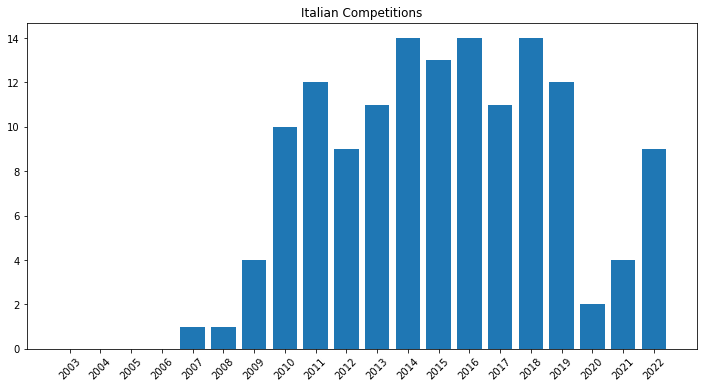

In [25]:
plt.figure
plt.bar(new['Year'], new['Competitions']);
plt.title('Italian Competitions');
plt.xticks(new['Year']);
plt.xticks(rotation=45);

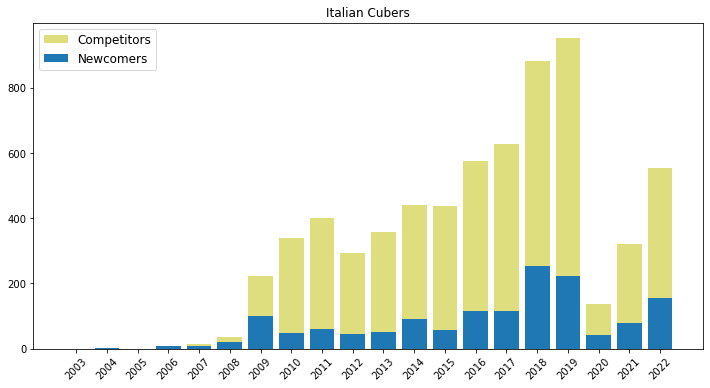

In [26]:
plt.figure
plt.bar(new['Year'], new['Competitors'], color = 'y', alpha = 0.5);
plt.bar(new['Year'], new['Newcomers']);
plt.title('Italian Cubers');
plt.legend(['Competitors','Newcomers'], fontsize = 12)
plt.xticks(new['Year']);
plt.xticks(rotation=45);

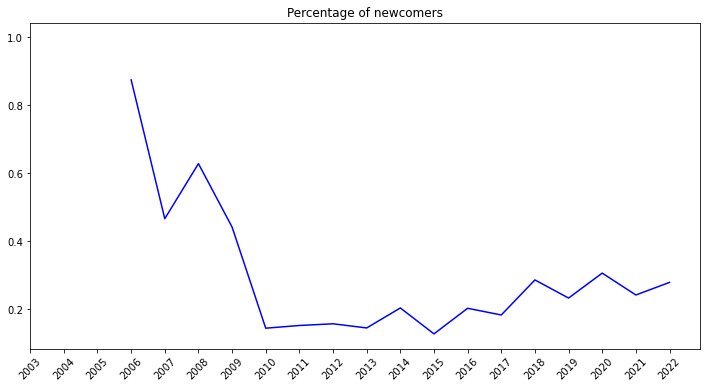

In [27]:
plt.figure
plt.plot(new['Year'], new['newcomer_ratio'], color = 'b');
plt.title('Percentage of newcomers');
plt.xticks(new['Year']);
plt.xticks(rotation=45);

Total number of italian competitors:

In [28]:
new['Newcomers'].sum()

1472

### Return Rate

Countries with at least 2 competitions:

In [29]:
d = df.groupby('countryId')['competitionId'].nunique()
countries2 = pd.DataFrame(d).reset_index(drop = False)
countries2 = list(countries2[countries2['competitionId'] >= 2]['countryId'])


In [30]:
dict_retrate = {}

for p in countries2:
    solve = df[df['personCountryId'] == p].copy() #only people from country p
    comps = list(solve.groupby('personId')['competitionId'].nunique()) #number of competitions for each ID
    
    competitors = len(comps) 
    returners = len([x for x in comps if x >= 2])
    
    if competitors > 25:
        dict_retrate[p] = (competitors, returners, truncate(100*returners / competitors , 2))
    else:
        dict_retrate[p] = (-1,-1,-1)

retrate = pd.DataFrame.from_dict(dict_retrate, orient="index").reset_index(drop=False)
retrate = retrate.rename(columns={"index":"Country", 0:"Competitors", 1:"Returners", 2:"Return Rate"})
retrate = retrate[retrate['Return Rate'] >= 0]

In [31]:
retrate = retrate.sort_values(by = 'Return Rate', ascending = False).reset_index(drop = True)
retrate.index += 1
retrate.head(10)

,Country,Competitors,Returners,Return Rate
1,Slovakia,176,102,57.95
2,Estonia,189,109,57.67
3,Czech Republic,376,207,55.05
4,Poland,3892,2130,54.72
5,Netherlands,1156,625,54.06
6,Switzerland,618,334,54.04
7,Belgium,536,288,53.73
8,Italy,1473,784,53.22
9,Latvia,218,116,53.21
10,Paraguay,153,81,52.94


53% of italian competitors competed at least twice (8th in the world)

### Regions competed in

Import the table

In [32]:
regions = pd.read_csv('competition+region.csv')

Add regions to the database

In [33]:
dfG = df.merge(regions, how='left', on = 'competitionId')

In [34]:
diff_regions = dfG.groupby('personId')['region'].nunique()

In [35]:
diff_regions = pd.DataFrame(diff_regions).reset_index(drop = False).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id').drop('id', 1)
diff_regions = diff_regions.rename(columns = {'personId':'WCAID','name':'Name','region':'Number of Regions'})
diff_regions = diff_regions[['WCAID', 'Name', 'Number of Regions']]
diff_regions = diff_regions.sort_values(by = 'Number of Regions', ascending = False).reset_index(drop = True)
diff_regions.index += 1
diff_regions.head(10)

,WCAID,Name,Number of Regions
1,2012NICO02,Alessandro Nicolì,12
2,2012CANT02,Simone Cantarelli,11
3,2007POLI01,Lorenzo Vigani Poli,11
4,2017GUID01,Carolina Guidetti,10
5,2014RAPO01,Tommaso Raposio,10
6,2009PROV01,Matteo Provasi,10
7,2009ROTA01,Marco Rota,9
8,2016PAOL01,Damiano Di Paola,9
9,2015MANN02,Marco Manno,9
10,2012CAPP01,Gabriele Cappelletti,9


### Regions with competitions

In [36]:
regions['region'].nunique()

14

Italy has had a WCA competition in 14 regions out of 20. We are missing:
- Valle d'Aosta
- Umbria
- Abruzzo
- Molise
- Basilicata
- Sardegna

### Regions with the most competitions

In [37]:
dict_regions = {
    'Lombardia':3, 
    'Lazio':12, 
    'Emilia-Romagna':8, 
    'Veneto':5, 
    'Toscana':9, 
    'Puglia':16, 
    'Campania':15, 
    'Piemonte':1, 
    'Sicilia':19, 
    'Liguria':7, 
    'Calabria':18, 
    'Friuli-VeneziaGiulia':6, 
    'Marche':11, 
    'Trentino-AltoAdige':4}
#copied from the istat coding system by hand

In [38]:
rr = regions.groupby('region').count().reset_index(drop = False)
rr = rr.sort_values(by = 'competitionId', ascending = False)
rr = rr.rename(columns = {'competitionId':'competitions'})
rr = rr.merge(pd.DataFrame.from_dict(dict_regions, orient = 'index').reset_index(drop = False), left_on = 'region', right_on = 'index')
rr = rr.drop('index',1).rename(columns = {0:'COD_REG'})

#insert missing regions as NAN
extra = [("Valled'Aosta", np.nan, 2),("Umbria", np.nan, 10),("Abruzzo", np.nan, 13),("Molise", np.nan, 14),("Basilicata", np.nan, 17),("Sardegna", np.nan, 20)] 

rr = pd.concat([rr,pd.DataFrame(extra, columns = rr.columns)], axis = 0).reset_index(drop = True)


In [39]:
#importing mapping libraries
import geopandas as gpd
import os

In [40]:
#opening shapefile, gathered from Istat
dfr = gpd.read_file(os.path.join("Limiti01012022/Reg01012022",'Reg01012022_WGS84.shp'))

In [41]:
dfr = dfr.merge(rr, on = 'COD_REG')

In [42]:
import matplotlib.cm as cm
import copy

mappa = copy.copy(cm.cool)
mappa.set_bad(color='white')

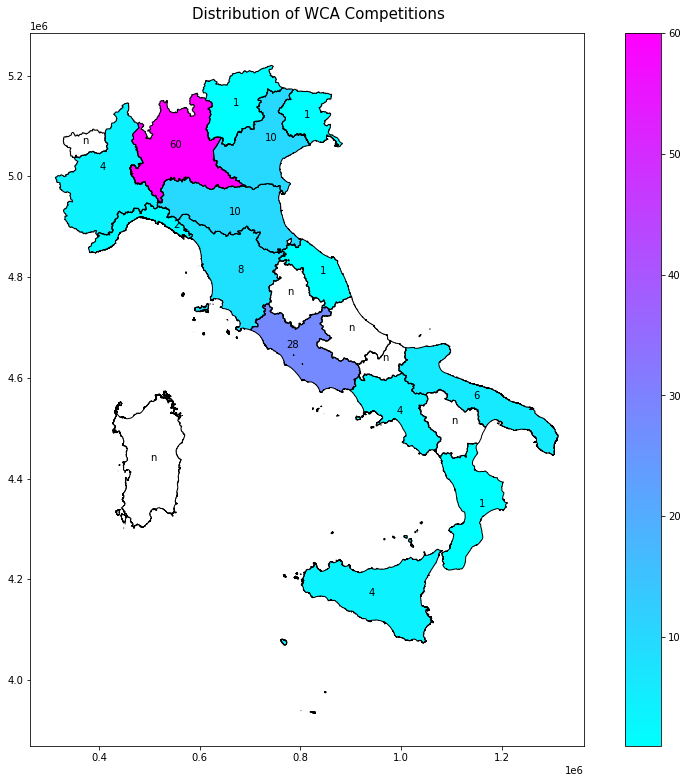

In [43]:
#joining model outputs to the shapefile
#map settings
fig, ax = plt.subplots(figsize = (15,12))
fig.subplots_adjust(top=0.95)
fig.suptitle('Distribution of WCA Competitions',fontsize = 15)
dfr.plot(column = 'competitions',cmap = mappa,ax=ax, legend=True)
dfr.geometry.boundary.plot(color=None,edgecolor='k',linewidth = 1,ax=ax) 

#adding labels
dfr['coords'] = dfr['geometry'].apply(lambda x: x.representative_point().coords[:])
dfr['coords'] = [coords[0] for coords in dfr['coords']]
for idx, row in dfr.iterrows():
    plt.annotate(text=str(round(row['competitions'],2))[:-2], xy=row['coords'],
                 horizontalalignment='center')

The map clearly shows an asymmetry in competition distribution. 
The north of Italy had a more active and consistent community throughout the years, and closer delegates. This lead to almost half of the total competitions being organized in Lombardia

# Events <a name="events"></a>

### Most Events Won

In [44]:
solve = df[df['personCountryId'] == 'Italy'] #solo italiani

persone = list(persons[persons['countryId'] == 'Italy']['id'].drop_duplicates())

dict_diff_gold = {}
golds = solve[(solve['roundTypeId'] == 'f') | (solve['roundTypeId'] == 'c')] #solo finali
golds = golds.replace([0,-1,-2],np.nan) # via dnf e cose strane
golds = golds.dropna(axis = 0, subset = ['best'])
golds = golds[golds['pos'] == 1] #solo ori

for p in persone:
    buffer = golds[golds['personId'] == p] #solo quella persona
    count = buffer['eventId'].nunique()
    nome = list(persons[persons['id'] == p]['name']).pop()
    buffer2 = solve[solve['personId'] == p]
    count2 = buffer2['eventId'].nunique()
    dict_diff_gold[p] = (nome, count, count2)
    
diff_gold = pd.DataFrame.from_dict(dict_diff_gold, orient="index").reset_index(drop=False)
diff_gold = diff_gold.rename(columns={"index":"WCAID", 0:"Name", 1:"Different Events Won", 2:"Events Competed In"})
diff_gold = diff_gold.sort_values(by = ['Different Events Won',"Events Competed In"], ascending = [False,True]).reset_index(drop = True)
diff_gold.index += 1
diff_gold.head(10)

,WCAID,Name,Different Events Won,Events Competed In
1,2014MAUR06,Lorenzo Mauro,13,18
2,2013FURL01,Mattia Furlan,11,14
3,2007POLI01,Lorenzo Vigani Poli,11,20
4,2013DISA01,Edoardo Disarò,10,17
5,2009CONT01,Giovanni Contardi,9,16
6,2009DIMP01,Mariano D'Imperio,9,20
7,2009MORI05,Paolo Moriello,8,13
8,2011TRON02,Sebastiano Tronto,8,17
9,2009IOVA01,Massimiliano Iovane,7,11
10,2008BRAN01,Filippo Brancaleoni,7,16


### Most Events Podiumed

In [45]:
solve = df[df['personCountryId'] == 'Italy'] #solo italiani

persone = list(persons[persons['countryId'] == 'Italy']['id'].drop_duplicates())

dict_diff_podiums = {}
podiums = solve[(solve['roundTypeId'] == 'f') | (solve['roundTypeId'] == 'c')] #solo finali
podiums = podiums.replace([0,-1,-2],np.nan) # via dnf e cose strane
podiums = podiums.dropna(axis = 0, subset = ['best'])
podiums = podiums[podiums['pos'] <= 3] #solo podi

for p in persone:
    buffer = podiums[podiums['personId'] == p] #solo quella persona
    count = buffer['eventId'].nunique()
    nome = list(persons[persons['id'] == p]['name']).pop()
    buffer2 = solve[solve['personId'] == p]
    count2 = buffer2['eventId'].nunique()
    dict_diff_podiums[p] = (nome, count, count2)
    
diff_podiums = pd.DataFrame.from_dict(dict_diff_podiums, orient="index").reset_index(drop=False)
diff_podiums = diff_podiums.rename(columns={"index":"Id", 0:"Name", 1:"Different Events with Podium", 2:"Events Competed In"})
diff_podiums = diff_podiums.sort_values(by = ['Different Events with Podium', 'Events Competed In'], ascending = [False, True]).reset_index(drop = True)
diff_podiums.index += 1
diff_podiums.head(10)

,Id,Name,Different Events with Podium,Events Competed In
1,2014MAUR06,Lorenzo Mauro,18,18
2,2009ROTA01,Marco Rota,18,20
3,2012NICO02,Alessandro Nicolì,17,18
4,2009DIMP01,Mariano D'Imperio,17,20
5,2008BRAN01,Filippo Brancaleoni,15,16
6,2017DUMM01,Matteo Dummar,15,18
7,2009CONT01,Giovanni Contardi,14,16
8,2007POLI01,Lorenzo Vigani Poli,14,20
9,2013FURL01,Mattia Furlan,13,14
10,2011TRON02,Sebastiano Tronto,13,17


### Most popular events - percent of Italians with a result in event

In [46]:
solve = df[df['personCountryId'] == 'Italy'] #solo italiani
solve = solve.replace([0,-1,-2],np.nan) # via dnf e cose strane
solve = solve.dropna(axis = 0, subset = ['best'])

italians = persons[persons['countryId'] == 'Italy']['id'].drop_duplicates().count()

dict_percent = {}
for e in event_list:
    buffer = solve[solve['eventId'] == e]
    count = buffer['personId'].nunique()
    dict_percent[e] = truncate(100 * count / italians , 2)
    
epercent = pd.DataFrame.from_dict(dict_percent, orient="index").reset_index(drop=False)
epercent = epercent.rename(columns={"index":"Event", 0:"Percent of Italians"})
epercent = epercent.sort_values(by = 'Percent of Italians', ascending = False).reset_index(drop = True)
epercent.index += 1
epercent

,Event,Percent of Italians
1,333,97.28
2,222,68.43
3,444,44.80
4,pyram,44.73
5,333oh,33.87
6,skewb,25.39
7,555,23.01
8,minx,17.65
9,sq1,13.71
10,333fm,10.31


This ranking can also be interpreted as a popularity score among italians

### Average Events per competition

In [47]:
compz = df[(df['countryId'] == 'Italy')]
gare = list(set(compz['competitionId']))

dict_avgevents = {}

for c in gare:
    subset = compz[compz['competitionId'] == c]
    count = subset['eventId'].nunique()
    count2 = subset.groupby('personId')['eventId'].nunique().mean()
    dict_avgevents[c] = (count, count2)
    
avgevents = pd.DataFrame.from_dict(dict_avgevents, orient="index").reset_index(drop=False)
avgevents = avgevents.rename(columns={"index":"Competition", 0:"Events", 1:"Avg Events per Competitor"})
avgevents = avgevents.sort_values(by = 'Avg Events per Competitor', ascending = False).reset_index(drop = True)
avgevents.index += 1
avgevents.head(10)

,Competition,Events,Avg Events per Competitor
1,ItalianChampionship2010,19,8.600000
2,LOLSouthItalianOpen2010,16,8.450000
3,ItalianChampionship2019,17,7.413408
4,ItalianChampionship2015,18,7.369565
5,ItalianChampionship2021,16,7.213235
6,ItalianOpen2017,17,6.918919
7,ItalianChampionship2016,17,6.903846
8,ItalianOpen2015,18,6.885714
9,TriesteOpen2013,11,6.875000
10,ItalianOpen2012,14,6.792453


In [48]:
avgevents.describe()

,Events,Avg Events per Competitor
count,141.000000,141.000000
mean,9.460993,4.740994
std,4.002709,1.322981
min,1.000000,1.000000
25%,7.000000,3.781250
50%,8.000000,4.576923
75%,12.000000,5.666667
max,19.000000,8.600000


Competitions in Italy have a mean of 9.46 events each (median at 8) with competitors doing only 4.74 of them on average.

# Results <a name="results"></a>

### Medal table

The medal table uses the 'weighted' criterium: golds are worth more than silvers that are worth more than gold

In [49]:
solve = df
solve = solve[solve['personCountryId'] == 'Italy'] #solo italiani
solve = solve[(solve['roundTypeId'] == 'f') | (solve['roundTypeId'] == 'c')] #solo finali
solve = solve[solve['pos'] <= 3] #solo podi
solve = solve.replace([0,-1,-2],np.nan) # via dnf e cose strane
solve = solve.dropna(axis = 0, subset = ['best'])

solve['bronze'] = solve[solve['pos'] == 3].groupby('personId')['personId'].transform('count')
solve['silver'] = solve[solve['pos'] == 2].groupby('personId')['personId'].transform('count')
solve['gold'] = solve[solve['pos'] == 1].groupby('personId')['personId'].transform('count')
solve['podiums'] = solve.groupby('personId')['personId'].transform('count')

In [50]:
medagliere_alltime = solve.groupby(['personId'])[['gold','silver','bronze','podiums']].count()
medagliere_alltime = medagliere_alltime.reset_index().merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id').drop('id', 1)
medagliere_alltime = medagliere_alltime.rename(columns = {'personId':'WCAID','name':'Name'})
medagliere_alltime = medagliere_alltime.sort_values(by= ['gold','silver','bronze'], ascending = [False,False,False]).reset_index(drop = True)
medagliere_alltime.index += 1
medagliere_alltime.head(10)

,WCAID,gold,silver,bronze,podiums,Name
1,2014MAUR06,116,67,45,228,Lorenzo Mauro
2,2013FURL01,113,26,22,161,Mattia Furlan
3,2009CONT01,70,38,43,151,Giovanni Contardi
4,2009MORI05,67,76,48,191,Paolo Moriello
5,2009IOVA01,66,40,22,128,Massimiliano Iovane
6,2011TRON02,63,35,17,115,Sebastiano Tronto
7,2008CIRN01,61,37,21,119,Fabrizio Cirnigliaro
8,2007POLI01,50,76,98,224,Lorenzo Vigani Poli
9,2009ROTA01,47,59,65,171,Marco Rota
10,2009COLO03,39,20,13,72,Matteo Colombo


The following is the same medal table ordered by number of podiums

In [51]:
medagliere_alltime = medagliere_alltime.sort_values(by= ['podiums'], ascending = False).reset_index(drop = True)
medagliere_alltime.index += 1
medagliere_alltime.head(10)

,WCAID,gold,silver,bronze,podiums,Name
1,2014MAUR06,116,67,45,228,Lorenzo Mauro
2,2007POLI01,50,76,98,224,Lorenzo Vigani Poli
3,2009MORI05,67,76,48,191,Paolo Moriello
4,2009ROTA01,47,59,65,171,Marco Rota
5,2013FURL01,113,26,22,161,Mattia Furlan
6,2009CONT01,70,38,43,151,Giovanni Contardi
7,2009IOVA01,66,40,22,128,Massimiliano Iovane
8,2009DIMP01,36,44,47,127,Mariano D'Imperio
9,2008CIRN01,61,37,21,119,Fabrizio Cirnigliaro
10,2011TRON02,63,35,17,115,Sebastiano Tronto


[Lorenzo Mauro](https://www.worldcubeassociation.org/persons/2014MAUR06) recently surpassed both [Mattia Furlan](https://www.worldcubeassociation.org/persons/2013FURL01) for golds and [Lorenzo Vigani Poli](https://www.worldcubeassociation.org/persons/2007POLI01) for total podiums in the medal table.

### Current best world rankings

The following are the best current world rankings of Italians in any event

In [52]:
solves = ranks_single[ranks_single['countryId'] == 'Italy'].copy() #solo italiani
solves['type'] = ['single' for x in solves['personId']]
solves = solves[['personId', 'name', 'eventId','type', 'best', 'worldRank']]
solves = solves.sort_values(by = ['worldRank', 'name'], ascending = [True, True]).reset_index(drop = True)

In [53]:
solvea = ranks_average[ranks_average['countryId'] == 'Italy'].copy() #solo italiani
solvea['type'] = ['average' for x in solvea['personId']]
solvea = solvea[['personId', 'name', 'eventId','type', 'best', 'worldRank']]
solvea = solvea.sort_values(by = ['worldRank', 'name'], ascending = [True, True]).reset_index(drop = True)

In [54]:
frames = [solves, solvea]
solveas = pd.concat(frames).sort_values(by = ['worldRank', 'name'], ascending = [True, True])
solveas = solveas[solveas['eventId'].isin(current_events)]
solveas = solveas.rename(columns = {'personId':'WCAID', 'name':'Name', 'eventId':'Event'}).reset_index(drop = True)
solveas.index += 1
solveas.head(20)

,WCAID,Name,Event,type,best,worldRank
1,2011TRON02,Sebastiano Tronto,333fm,single,16,1
2,2011TRON02,Sebastiano Tronto,333fm,average,2200,4
3,2018RICC02,Alessandro Ricci,sq1,average,663,9
4,2014RAPO01,Tommaso Raposio,333fm,average,2333,14
5,2013FURL01,Mattia Furlan,666,single,8666,16
6,2013FURL01,Mattia Furlan,666,average,9427,16
7,2013FURL01,Mattia Furlan,777,average,13619,18
8,2014RAPO01,Tommaso Raposio,333fm,single,20,18
9,2013FURL01,Mattia Furlan,777,single,12969,20
10,2011TRON02,Sebastiano Tronto,333bf,average,2227,26


[Sebastiano Tronto](https://www.worldcubeassociation.org/persons/2011TRON02) holds the world record for FMC single and the european record for FMC mean

### Most top 10 rankings

In [55]:
solves = ranks_single[ranks_single['countryId'] == 'Italy'].copy() #solo italiani
solves = solves[solves['eventId'].isin(current_events)]
solves = solves[(solves['countryRank'] <= 10) & (0 < solves['countryRank'])]
solves = solves.groupby('personId')['countryRank'].count()

solvea = ranks_average[ranks_average['countryId'] == 'Italy'].copy() #solo italiani
solvea = solvea[solvea['eventId'].isin(current_events)]
solvea = solvea[(solvea['countryRank'] <= 10) & (0 < solvea['countryRank'])]
solvea = solvea.groupby('personId')['countryRank'].count()

totrank = (solves + solvea).fillna(0)
totrank = pd.DataFrame(totrank).reset_index(drop = False).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id').drop('id', 1)
totrank = totrank.rename(columns = {'countryRank':'Number of Top10 Rankings'})
totrank = totrank[['personId', 'name', 'Number of Top10 Rankings']]
totrank = totrank.rename(columns = {'personId':'WCAID', 'name':'Name'})
totrank = totrank.sort_values(by = 'Number of Top10 Rankings', ascending = False).reset_index(drop = True)
totrank.index += 1
totrank = totrank.astype({"Number of Top10 Rankings": int})
totrank.head(20)

,WCAID,Name,Number of Top10 Rankings
1,2014MAUR06,Lorenzo Mauro,28
2,2013FURL01,Mattia Furlan,16
3,2009CONT01,Giovanni Contardi,13
4,2012NICO02,Alessandro Nicolì,13
5,2009ROTA01,Marco Rota,12
6,2009IOVA01,Massimiliano Iovane,11
7,2017BRAS01,Luca Brasini,10
8,2017DUMM01,Matteo Dummar,10
9,2011TRON02,Sebastiano Tronto,10
10,2009MORI05,Paolo Moriello,9


Out of 17 rankings for single and 16 rankings for average (33 total), [Lorenzo Mauro](https://www.worldcubeassociation.org/persons/2014MAUR06) is among the 10 best italians in 28 of them

### Best podium of all time

In [56]:
solve = df
solve = solve[solve['countryId'] == 'Italy'] #solo gare in italia
solve = solve[solve['eventId'] == '333'] #solo 333
solve = solve[(solve['roundTypeId'] == 'f') | (solve['roundTypeId'] == 'c')] #solo finali
solve = solve[solve['pos'] <= 3] #solo podi
solve = solve.replace([0,-1,-2],np.nan) # via dnf e cose strane
#solve = solve.dropna(axis = 0, subset = ['average'])

gare = list(set(solve['competitionId']))

dict_bestpodiums = {}

for c in gare:
    subset = solve[solve['competitionId'] == c]
    subset = subset.sort_values(by = 'pos', ascending = True)
    count = subset['average'].sum()
    dict_bestpodiums[c] = (count, subset.iloc[0,6], subset.iloc[0,5], subset.iloc[1,6], subset.iloc[1,5], subset.iloc[2,6], subset.iloc[2,5])
    
bestpodiums = pd.DataFrame.from_dict(dict_bestpodiums, orient="index").reset_index(drop=False)
bestpodiums = bestpodiums.rename(columns={"index":"Competition", 0:"Best Podium", 1:"First", 2:"Average1", 3:"Second", 4:"Average2", 5:"Third", 6:"Average3",})
bestpodiums = bestpodiums.sort_values(by = 'Best Podium', ascending = True).reset_index(drop = True)
bestpodiums['Best Podium'] = bestpodiums['Best Podium'] / 100
bestpodiums['Average1'] = bestpodiums['Average1'] / 100
bestpodiums['Average2'] = bestpodiums['Average2'] / 100
bestpodiums['Average3'] = bestpodiums['Average3'] / 100
bestpodiums.index += 1
bestpodiums.head(10)

,Competition,Best Podium,First,Average1,Second,Average2,Third,Average3
1,BolognaSummerOpen2021,22.57,Juliette Sébastien,7.20,Valerio Locatelli,7.52,Lucas Déglise,7.85
2,PaladiamanteOpen2022,23.15,Valerio Locatelli,7.42,Juliette Sébastien,7.45,Nicolas Gertner,8.28
3,BolognaBackfromHolidays2021,23.54,Valerio Locatelli,7.15,Juliette Sébastien,8.05,Daniel Sartori,8.34
4,BolognaNewYear2022,24.36,Juliette Sébastien,7.19,Florian Truckenthanner,8.51,Luca Brasini,8.66
5,ItalianChampionship2019,24.40,Nicolas Gertner,8.04,Mattia Galentino,8.05,Giovanni Contardi,8.31
6,ItalianChampionship2021,24.62,Valerio Locatelli,7.95,Lucas Déglise,8.25,Juliette Sébastien,8.42
7,SPQROpen2022,25.21,Valerio Locatelli,7.23,Flavio Rimi,8.97,Ianis Costin Chele,9.01
8,SarzanaSeasideCubing2022,25.27,Ianis Costin Chele,8.17,Kaur Tuule,8.44,Giacomo Daniele Corò,8.66
9,BolognaNxNSpring2019,25.78,Massimiliano Iovane,8.40,Mattia Galentino,8.56,Giovanni Contardi,8.82
10,SalentoCubingOpen2020,25.94,Mattia Galentino,8.01,János Bereczki,8.36,Alessandro Nicolì,9.57


The best all-italian podium is ranked only 9th among the fastest podiums registered on Italian soil.

### Best first Average

In [57]:
solve = df[df['personCountryId'] == 'Italy'].copy() #solo italiani
solve = solve[solve['eventId'] == '333'] 
solve = solve.replace([0,-1,-2],np.nan) # via dnf e cose strane

bestfirst = solve.groupby('personId')['average'].nth(0)
bestfirst = pd.DataFrame(bestfirst).reset_index().merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id').drop('id', 1)
bestfirst = bestfirst[['personId', 'name', 'average']]
bestfirst = bestfirst.dropna()
bestfirst['average'] = bestfirst['average'].astype({"average": int}) / 100
bestfirst = bestfirst.rename(columns = {'personId':'WCAID','name':'Name', 'average':'Best First Average'})
bestfirst = bestfirst.dropna().sort_values(by = 'Best First Average', ascending = True).reset_index(drop = True)
bestfirst.index += 1
bestfirst.head(10)


,WCAID,Name,Best First Average
1,2022RIBE02,Vittorio Ribechini,10.07
2,2019CAMI03,Davide Camilleri,10.84
3,2012MURC01,Davide Murciano,11.41
4,2021NARB01,Dario Angelo Narbone,11.66
5,2021ITAL02,Manfredi Italiano,12.49
6,2021SALE01,Sofia Saletnich,12.66
7,2021BAND01,Matilde Bandini,12.71
8,2019BAZZ01,Giovanni Bazzani,12.73
9,2019GIOR02,Marco Giordano,12.82
10,2022MACC01,Evan Maccagnan,13.02


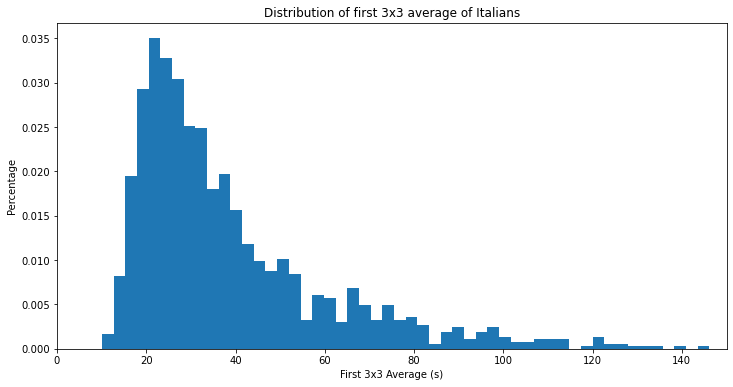

In [58]:
plt.hist(bestfirst['Best First Average'], density=True, bins=100)  # density=False would make counts
plt.ylabel('Percentage')
plt.xlim(0,150)
plt.xlabel('First 3x3 Average (s)')
plt.title('Distribution of first 3x3 average of Italians')
plt.show()

In [59]:
bestfirst['Best First Average'].describe()

count    1397.000000
mean       40.727480
std        28.294217
min        10.070000
25%        23.260000
50%        32.030000
75%        48.170000
max       271.780000
Name: Best First Average, dtype: float64

On average, Italians at the first competitions score a 40.73 3x3 average (median is lower: 32.03)

# Records <a name="records"></a>

### Italian World and Continental records

In [60]:
records = df[df['personCountryId'] == 'Italy'] #solo italiani
records = records[(records['regionalSingleRecord'] == 'WR') | (records['regionalAverageRecord'] == 'WR')|(records['regionalSingleRecord'] == 'ER') | (records['regionalAverageRecord'] == 'ER')]
records = records[['personId','personName','competitionId','year','eventId','best','average','regionalSingleRecord','regionalAverageRecord']]
records.loc[records['regionalSingleRecord']=='NR', 'regionalSingleRecord'] = np.nan
records.loc[records['regionalAverageRecord']=='NR', 'regionalAverageRecord'] = np.nan
            

In [61]:
recordsg = records.groupby('year')['regionalSingleRecord'].apply(lambda x: (x=='WR').sum()).reset_index(name='WRcount') + records.groupby('year')['regionalAverageRecord'].apply(lambda x: (x=='WR').sum()).reset_index(name='WRcount')
ers = records.groupby('year')['regionalSingleRecord'].apply(lambda x: (x=='ER').sum()).reset_index(name='ERcount') + records.groupby('year')['regionalAverageRecord'].apply(lambda x: (x=='ER').sum()).reset_index(name='ERcount')
recordsg['ERcount'] = ers['ERcount']
recordsg['year'] = recordsg['year'] / 2
extra = [(2003, 0, 0), (2004, 0, 0), (2005, 0, 0), (2006, 0, 0), (2007, 0, 0), (2008, 0, 0), (2009, 0, 0), (2020, 0, 0), (2021, 0, 0), (2022, 0, 0)]
recordsg = pd.concat([recordsg,pd.DataFrame(extra, columns = recordsg.columns)], axis = 0).reset_index(drop = True)
recordsg = recordsg.astype(int)
recordsg = recordsg.sort_values(by = 'year')

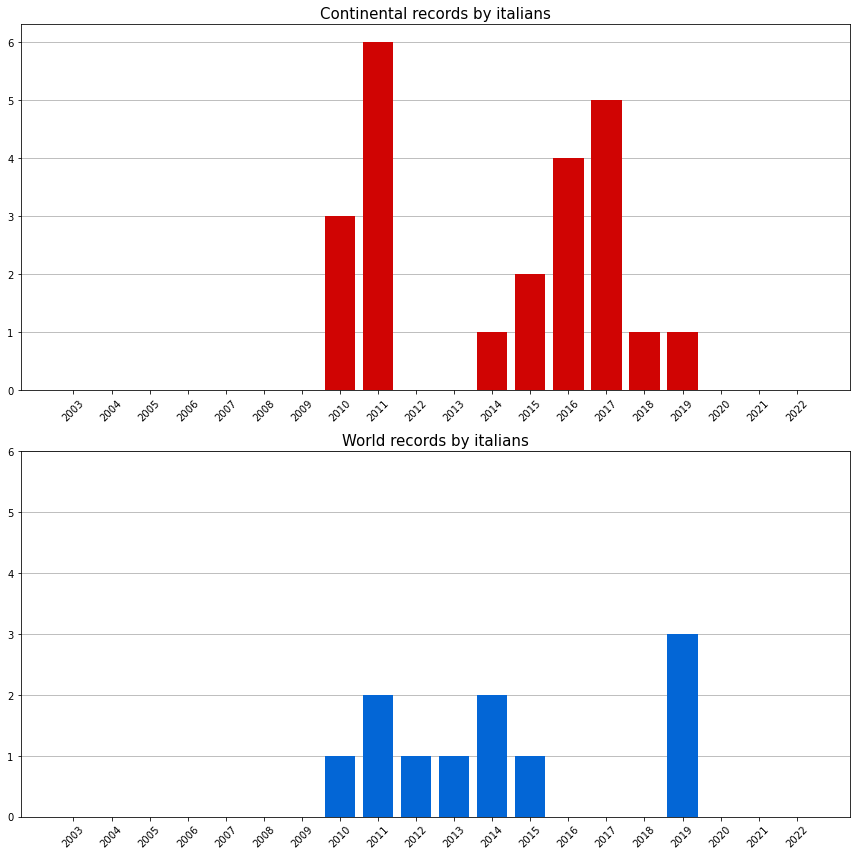

In [62]:
fig = plt.figure(figsize = (12,12))

plt.subplot(2, 1, 1)
plt.bar(recordsg['year'], recordsg['ERcount'], color = '#D00403', zorder=3);
plt.xticks(recordsg['year']);
plt.xticks(rotation=45);
plt.title('Continental records by italians', fontsize = 15);
plt.grid(axis = 'y')

plt.subplot(2, 1, 2)
plt.bar(recordsg['year'], recordsg['WRcount'], color = '#0366D6', zorder=3);
plt.xticks(recordsg['year']);
plt.xticks(rotation=45);
plt.title('World records by italians', fontsize = 15);
plt.ylim(0,6)
plt.grid(axis = 'y')

plt.tight_layout()

### Evolution of 3x3 NRs

In [63]:
import datetime

In [64]:
nr = df[df['personCountryId'] == 'Italy'] #solo italiani

nrs = nr[(nr['regionalSingleRecord'] == 'NR') & (nr['eventId'] == '333')].copy(deep = True)
nrs['date'] = pd.to_datetime(nrs[['year','month','day']])
nrs = nrs[['personId','personName','best','date']].sort_values(by = ['date','best'], ascending = [True,False]).reset_index(drop = True)
nrs = nrs.rename(columns = {'personId':'WCAID','personName':'Name','best':'NR single'})
nrs['NR single'] = nrs['NR single'] / 100

nra = nr[(nr['regionalAverageRecord'] == 'NR') & (nr['eventId'] == '333')].copy(deep = True)
nra['date'] = pd.to_datetime(nra[['year','month','day']])
nra = nra[['personId','personName','average','date']].sort_values(by = ['date','average'], ascending = [True,False]).reset_index(drop = True)
nra = nra.rename(columns = {'personId':'WCAID','personName':'Name','average':'NR average'})
nra['NR average'] = nra['NR average'] / 100

wrs = df[(df['regionalSingleRecord'] == 'WR') & (df['eventId'] == '333')].copy(deep = True)
wrs['date'] = pd.to_datetime(wrs[['year','month','day']])
wrs = wrs[['personId','personName','best','date']].sort_values(by = ['date','best'], ascending = [True,False]).reset_index(drop = True)
wrs = wrs.rename(columns = {'personId':'WCAID','personName':'Name','best':'WR single'})
wrs['WR single'] = wrs['WR single'] / 100

wra = df[(df['regionalAverageRecord'] == 'WR') & (df['eventId'] == '333')].copy(deep = True)
wra['date'] = pd.to_datetime(wra[['year','month','day']])
wra = wra[['personId','personName','average','date']].sort_values(by = ['date','average'], ascending = [True,False]).reset_index(drop = True)
wra = wra.rename(columns = {'personId':'WCAID','personName':'Name','average':'WR average'})
wra['WR average'] = wra['WR average'] / 100

History of national record singles

In [65]:
nrs

,WCAID,Name,NR single,date
0,1982ROME01,Giuseppe Romeo,28.11,1982-06-05
1,2007CHIM01,Giulio Chiminelli,23.28,2007-05-26
2,2007CHIM01,Giulio Chiminelli,16.78,2007-05-26
3,2007POLI01,Lorenzo Vigani Poli,14.96,2008-06-21
4,2008ROSS01,Paolo Rosson,14.93,2008-11-08
5,2008ROSS01,Paolo Rosson,12.47,2008-11-08
6,2009BEVA01,Stefano Bevacqua,12.08,2009-09-19
7,2009IOVA01,Massimiliano Iovane,11.02,2009-10-09
8,2008BRAN01,Filippo Brancaleoni,9.28,2009-12-29
9,2009CONT01,Giovanni Contardi,8.96,2010-05-09


History of national record averages

In [66]:
nra

,WCAID,Name,NR average,date
0,2007SCIB01,Emanuele Scibilia,25.96,2007-05-26
1,2007CHIM01,Giulio Chiminelli,20.90,2007-05-26
2,2007POLI01,Lorenzo Vigani Poli,19.67,2008-02-02
3,2008ROSS01,Paolo Rosson,19.25,2008-06-21
4,2007POLI01,Lorenzo Vigani Poli,17.40,2008-06-21
5,2008ROSS01,Paolo Rosson,17.39,2008-11-08
6,2007POLI01,Lorenzo Vigani Poli,16.76,2008-11-08
7,2007POLI01,Lorenzo Vigani Poli,16.70,2009-02-14
8,2007POLI01,Lorenzo Vigani Poli,16.44,2009-08-08
9,2007POLI01,Lorenzo Vigani Poli,15.34,2009-08-08


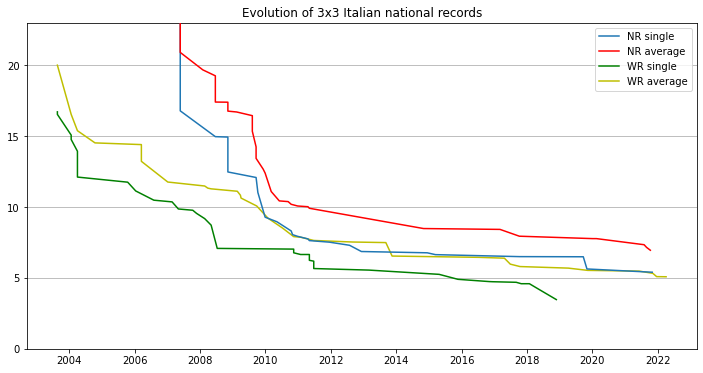

In [67]:
plt.figure
plt.plot(nrs['date'][1:],nrs['NR single'][1:], zorder=3);
plt.plot(nra['date'],nra['NR average'], color = 'r', zorder=3);
plt.plot(wrs['date'][1:],wrs['WR single'][1:], color = 'g');
plt.plot(wra['date'],wra['WR average'], color = 'y');
plt.title('Evolution of 3x3 Italian national records');
plt.legend(['NR single','NR average', 'WR single','WR average'])
plt.ylim(0,23)

plt.grid(axis = 'y')

The current national records are held by [Valerio Locatelli](https://www.worldcubeassociation.org/persons/2018LOCA01).

# Relays <a name="relays"></a>

A series of relay times calculated with official personal records

### 2-7 "Official" Releay

2-7 relay is all NxN events recognized by the WCA

In [68]:
solve = ranks_single[ranks_single['countryId'] == 'Italy'] #only italians

persone = list(persons[persons['countryId'] == 'Italy']['id'].drop_duplicates()) #list of WCAID

dict_relay = {}
eventi = ['222', '333', '444', '555', '666', '777'] #select events you want to do the rankings

for p in persone: #for every person
    time = 0
    nome = list(persons[persons['id'] == p]['name']).pop() #get the name
    buffer = solve[solve['personId'] == p]
    buffer = buffer[buffer['eventId'].isin(eventi)] #filter for the best single in all the events
    if buffer.shape[0] < len(eventi): #if they don't have all singles, assign a really high time
        time = 10**7
        dict_relay[p] = (nome, time)
    else:
        time = buffer['best'].sum() #if they have all, sum them
        dict_relay[p] = (nome, time / 100)
    
relay = pd.DataFrame.from_dict(dict_relay, orient="index").reset_index(drop=False) #create the table
relay = relay.rename(columns={"index":"Id", 0:"Name", 1:"Official 2-7 Relay"})
relay = relay.sort_values(by = 'Official 2-7 Relay', ascending = True).reset_index(drop = True)
relay.index += 1

In [69]:
import time

In [70]:
relay['Official 2-7 Relay'] = [time.strftime('%M:%S', time.gmtime(x)) for x in relay['Official 2-7 Relay']]
relay.head(10)

,Id,Name,Official 2-7 Relay
1,2013FURL01,Mattia Furlan,04:55
2,2017BRAS01,Luca Brasini,06:29
3,2016GAMM01,Vincenzo Maria Gammino,06:36
4,2009CONT01,Giovanni Contardi,06:39
5,2016GASP01,Pietro Gasparetto,06:39
6,2009IOVA01,Massimiliano Iovane,07:04
7,2009MORI05,Paolo Moriello,07:10
8,2014MAUR06,Lorenzo Mauro,07:17
9,2018CILI01,Simone Cilia,07:26
10,2015MANN02,Marco Manno,07:28


### "Official" Guilfod Challenge

Guilford Challenge is all non-blindfolded (+FMC) events

In [71]:
persone = list(persons[persons['countryId'] == 'Italy']['id'].drop_duplicates())

dict_guilf = {}
eventi = ['222', '333', '444', '555', '666', '777', 'clock', 'minx', 'pyram', 'skewb', '333oh', 'sq1']

for p in persone:
    time = 0
    nome = list(persons[persons['id'] == p]['name']).pop()
    buffer = solve[solve['personId'] == p]
    buffer = buffer[buffer['eventId'].isin(eventi)]
    if buffer.shape[0] < len(eventi):
        time = 10**15
        dict_guilf[p] = (nome, time)
    else:
        time = buffer['best'].sum()
        dict_guilf[p] = (nome, time / 100)
    
guilf = pd.DataFrame.from_dict(dict_guilf, orient="index").reset_index(drop=False)
guilf = guilf.rename(columns={"index":"WCAID", 0:"Name", 1:"Official Guilford Challenge"})
guilf = guilf.sort_values(by = 'Official Guilford Challenge', ascending = True).reset_index(drop = True)
guilf.index += 1

In [72]:
import time

In [73]:
guilf['Official Guilford Challenge'] = [time.strftime('%M:%S', time.gmtime(x)) for x in guilf['Official Guilford Challenge']]
guilf.head(10)


,WCAID,Name,Official Guilford Challenge
1,2013FURL01,Mattia Furlan,06:16
2,2014MAUR06,Lorenzo Mauro,08:38
3,2017BRAS01,Luca Brasini,08:47
4,2019GIOR02,Marco Giordano,09:24
5,2013DISA01,Edoardo Disarò,09:27
6,2009ROTA01,Marco Rota,09:36
7,2018CENT02,Giovanni Centili,09:40
8,2016GASP01,Pietro Gasparetto,09:47
9,2007POLI01,Lorenzo Vigani Poli,10:07
10,2016FURB01,Pietro Furbatto,10:19


### "Official Mini Guilford"

Mini Guilford Challenge is all events in the format "average of 5"

In [74]:
solve = ranks_single[ranks_single['countryId'] == 'Italy'] #solo italiani

persone = list(persons[persons['countryId'] == 'Italy']['id'].drop_duplicates())

dict_mguilf = {}
eventi = ['222', '333', '444', '555', 'clock', 'minx', 'pyram', 'skewb', '333oh', 'sq1']

for p in persone:
    time = 0
    nome = list(persons[persons['id'] == p]['name']).pop()
    buffer = solve[solve['personId'] == p]
    buffer = buffer[buffer['eventId'].isin(eventi)]
    if buffer.shape[0] < len(eventi):
        time = 10**15
        dict_mguilf[p] = (nome, time)
    else:
        time = buffer['best'].sum()
        dict_mguilf[p] = (nome, time / 100)
    
mguilf = pd.DataFrame.from_dict(dict_mguilf, orient="index").reset_index(drop=False)
mguilf = mguilf.rename(columns={"index":"WCAID", 0:"Name", 1:"Official Mini-Guilford Challenge"})
mguilf = mguilf.sort_values(by = 'Official Mini-Guilford Challenge', ascending = True).reset_index(drop = True)
mguilf.index += 1
mguilf.head(10)

,WCAID,Name,Official Mini-Guilford Challenge
1,2013FURL01,Mattia Furlan,160.46
2,2014MAUR06,Lorenzo Mauro,181.11
3,2018CENT02,Giovanni Centili,204.51
4,2009ROTA01,Marco Rota,210.93
5,2018RIMI01,Flavio Rimi,212.92
6,2013DISA01,Edoardo Disarò,222.87
7,2019GIOR02,Marco Giordano,222.98
8,2014RAPO01,Tommaso Raposio,231.98
9,2012NICO02,Alessandro Nicolì,233.44
10,2017BRAS01,Luca Brasini,233.92


In [75]:
import time

In [76]:
mguilf['Official Mini-Guilford Challenge'] = [time.strftime('%M:%S', time.gmtime(x)) for x in mguilf['Official Mini-Guilford Challenge']]
mguilf.head(10)

,WCAID,Name,Official Mini-Guilford Challenge
1,2013FURL01,Mattia Furlan,02:40
2,2014MAUR06,Lorenzo Mauro,03:01
3,2018CENT02,Giovanni Centili,03:24
4,2009ROTA01,Marco Rota,03:30
5,2018RIMI01,Flavio Rimi,03:32
6,2013DISA01,Edoardo Disarò,03:42
7,2019GIOR02,Marco Giordano,03:42
8,2014RAPO01,Tommaso Raposio,03:51
9,2012NICO02,Alessandro Nicolì,03:53
10,2017BRAS01,Luca Brasini,03:53


### 'Official' Lucky Relay

Lucky relay is 2x2, skewb and pyraminx

In [77]:
solve = ranks_single[ranks_single['countryId'] == 'Italy'] #solo italiani

persone = list(persons[persons['countryId'] == 'Italy']['id'].drop_duplicates())

dict_lucky = {}
eventi = ['222', 'pyram', 'skewb']

for p in persone:
    time = 0
    nome = list(persons[persons['id'] == p]['name']).pop()
    buffer = solve[solve['personId'] == p]
    buffer = buffer[buffer['eventId'].isin(eventi)]
    if buffer.shape[0] < len(eventi):
        time = 10**15
        dict_lucky[p] = (nome, time)
    else:
        time = buffer['best'].sum()
        dict_lucky[p] = (nome, time / 100)
    
lucky = pd.DataFrame.from_dict(dict_lucky, orient="index").reset_index(drop=False)
lucky = lucky.rename(columns={"index":"WCAID", 0:"Name", 1:"Official 2-pyra-skewb Relay"})
lucky = lucky.sort_values(by = 'Official 2-pyra-skewb Relay', ascending = True).reset_index(drop = True)
lucky.index += 1
lucky.head(10)

,WCAID,Name,Official 2-pyra-skewb Relay
1,2014MAUR06,Lorenzo Mauro,4.44
2,2018ARNE04,Davide Arnesano,5.44
3,2009ROTA01,Marco Rota,5.93
4,2018CENT02,Giovanni Centili,6.33
5,2017DUMM01,Matteo Dummar,6.66
6,2019GIOR02,Marco Giordano,6.90
7,2012NICO02,Alessandro Nicolì,7.06
8,2018RIMI01,Flavio Rimi,7.29
9,2015BOND02,Marianna Bondi,7.64
10,2016TADD01,Filippo Taddei,8.12
